In [1]:
# Versioni FISSATE: sono quelle con cui la pipeline ha funzionato (sessioni del 4 ottobre 2026).
# Non installare "vllm" senza versione: un aggiornamento di huggingface_hub (2.x)
# ha rotto l'import di transformers e vLLM non partiva piu'.
!pip uninstall -y vllm torch torchvision torchaudio torchcodec
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install "vllm==0.30.0" "transformers==5.18.0" "huggingface_hub==1.33.0" "tokenizers==0.23.2"
!pip uninstall -y torchcodec


Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Found existing installation: torchcodec 0.11.0+cu128
Uninstalling torchcodec-0.11.0+cu128:
  Successfully uninstalled torchcodec-0.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.3 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)
ERROR: No matching distribution found for torchaudio
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 2.8 MB/s eta 0:0

# Analisi e Simulazione: La co-evoluzione di un sistema agentico in una rete sociale
## Pipeline Completa: Fase 0 → Fase 1 → Fase 2 → Fase 3

Questo notebook esegue la pipeline completa del framework in sequenza.

| Fase | Titolo | Moduli chiave |
|------|--------|---------------|
| **0** | Setup & Baseline | `data_loader`, `extractor` (Forest Fire sampling), `community`, `metrics` |
| **1** | Logica Agente | `agent`, `llm_client`, `state_machine`, `seeder` |
| **2** | Co-evoluzione | `orchestrator`, `gnn`, `rewirer`, `checkpoint` |
| **3** | CELF Fact-Checking | `celf`, `injector`, `influence/metrics` |

> [Setup]️ **Configurazione**: modifica `config.yaml` o i parametri nella cella di setup per personalizzare la simulazione.
>
> [Graph] **Sampling**: il sottografo viene estratto con l'algoritmo **Forest Fire** (Leskovec & Faloutsos, KDD 2006) che preserva meglio le proprietà strutturali (distribuzione gradi, clustering, comunità) rispetto a BFS/Random Walk.

## 0. Setup Ambiente

In [2]:
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_1 = user_secrets.get_secret("HF_TOKEN")


os.environ["HF_TOKEN"] = secret_value_1

print("[Done] Variabili d'ambiente impostate:")
print(f"   HF_TOKEN       = {'*' * 8}{secret_value_1[-4:]}")

import site
os.environ["LD_LIBRARY_PATH"] = f"{site.getsitepackages()[0]}/nvidia/cuda_nvrtc/lib:" + os.environ.get("LD_LIBRARY_PATH", "")


[Done] Variabili d'ambiente impostate:
   HF_TOKEN       = ********GZkB


In [3]:
import sys
import os
from pathlib import Path

# --- Path setup (compatibile locale + Kaggle) ---
if Path('/kaggle/working').exists():
    # Kaggle: clona il repo nella working dir
    PROJECT_ROOT = Path('/kaggle/working/progetto')
    if not PROJECT_ROOT.exists():
        os.system('git clone https://github.com/stefaano19/progettoASM /kaggle/working/progetto')
        os.system('NUMPY_VER=$(python -c "import numpy; print(numpy.__version__)") && pip install -r /kaggle/working/progetto/requirements.txt && pip install --force-reinstall --no-deps numpy==$NUMPY_VER')
else:
    # Locale: la project root è due livelli sopra il notebook
    PROJECT_ROOT = Path('..').resolve()

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version}')

Cloning into '/kaggle/working/progetto'...


INFO: pip is looking at multiple versions of notebook to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.2/123.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.6/394.6 kB 23.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.2
    Uninstalling protobuf-7.36.2:
      Successfully uninstalled protobuf-7.36.2
  Attempting uninstall: jupyter-client
    Found existi

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.30.0 requires torchcodec>=0.14, which is not installed.
bigframes 2.48.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.4.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.20.0, but you have jupyter-server 2.21.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter_client<8.0,>=5.2.0, but you have jupyter-client 8.10.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires notebook<7.0,>=5.7.6, but you have notebook 7.6.3 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 94.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
Project root: /kaggle/working/progetto
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [4]:
# 4. Installa i requirement del progetto
!pip install -r requirements.txt


## 0.1 Setup vLLM (LLM locale)
Gli agenti usano un server **vLLM** locale (API compatibile OpenAI) con il modello Llama 3 8B Instruct quantizzato AWQ. vLLM fa *continuous batching*: le centinaia di chiamate di ogni step vengono elaborate in parallelo.


In [5]:
# --- Download preventivo per evitare instabilità di rete (403 Forbidden) ---
!pip install -U huggingface_hub
!hf download casperhansen/llama-3-8b-instruct-awq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.0/838.0 kB 13.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.33.0
    Uninstalling huggingface_hub-1.33.0:
      Successfully uninstalled huggingface_hub-1.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.30.0 requires torchcodec>=0.14, which is not installed.
tokenizers 0.23.2 requires huggingface-hub<2.0,>=0.16.4, but you have huggingface-hub 2.1.1 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 2.1.1 which is incompatible.
datasets 4.8.5 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 2.1.1 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 2.1.1 which is incompatible.
gradio-client 2.6.1 requires huggingfa

In [6]:
# --- Avvio server vLLM (OpenAI Compatible) ---
import subprocess, os, time

# Modello AWQ quantizzato (4 bit): sta in una singola T4 da 15 GB.
MODEL_NAME = "casperhansen/llama-3-8b-instruct-awq"
# 1 = una sola T4. 2 = tensor parallel su entrambe le T4 (piu' veloce).
# Con 2 la Fase 2 passa da ~12 a ~6 minuti per step (provato il 4 ottobre 2026).
VLLM_TENSOR_PARALLEL = 2

env = os.environ.copy()
env['VLLM_ATTENTION_BACKEND'] = 'xformers'
env['VLLM_DISABLE_MARLIN'] = '1'
env['VLLM_USE_MARLIN'] = '0'
subprocess.Popen(
    ['python', '-m', 'vllm.entrypoints.openai.api_server',
     '--model', MODEL_NAME,
     '--quantization', 'awq',
     '--dtype', 'half',
     '--max-model-len', '4096',
     '--port', '8000',
     '--gpu-memory-utilization', '0.90',
     '--tensor-parallel-size', str(VLLM_TENSOR_PARALLEL)],
    stdout=open('vllm.log', 'w'),
    stderr=subprocess.STDOUT,
    env=env,
)
print("[Pending] Avvio vLLM in background (potrebbe richiedere 1-3 minuti)...\n")
time.sleep(10) # Pausa iniziale


[Pending] Avvio vLLM in background (potrebbe richiedere 1-3 minuti)...



In [7]:
import requests, time

# Healthcheck vLLM
ok = False
for i in range(40):
    try:
        response = requests.get('http://localhost:8000/v1/models', timeout=2)
        if response.status_code == 200:
            ok = True
            break
    except Exception:
        pass
    time.sleep(5)

if ok:
    models = [m['id'] for m in response.json().get('data', [])]
    print(f'[Done] vLLM è online! Modelli: {models}')
else:
    print('[Failed] Errore: vLLM non sta rispondendo')
    !tail -n 30 vllm.log
    # Ferma il notebook: senza LLM la simulazione girerebbe "a vuoto"
    # (nessuna transizione) producendo risultati non validi.
    raise RuntimeError('vLLM non e\' partito: controlla vllm.log sopra. Simulazione interrotta.')


[Done] vLLM è online! Modelli: ['casperhansen/llama-3-8b-instruct-awq']


In [8]:
# Parametri globali della pipeline
# Modifica qui invece di editare config.yaml

CONFIG_PATH       = 'config.yaml'
USE_MOCK_LLM      = False       # False = usa il vero LLM (vLLM)
PHASE2_STEPS      = 0          # N. step da eseguire IN QUESTA SESSIONE (non totali!)
PHASE3_STEPS      = 30           # Step post-intervento (0 nelle sessioni intermedie di Fase 2)
CELF_BUDGET_K     = 20          # Fact-checker da iniettare
SKIP_DOWNLOAD     = True        # True se ogbl-collab e' gia' in cache
RESUME_FROM_CKPT  = True       # True per riprendere da checkpoint Fase 2

# --- Fase 3: intervento vs controllo ---
# Per misurare l'effetto dei fact-checker servono DUE sessioni di Fase 3,
# entrambe dallo stesso checkpoint finale di Fase 2 e con gli stessi PHASE3_STEPS:
#   1. CONTROL_RUN = False -> CELF + iniezione dei fact-checker
#   2. CONTROL_RUN = True  -> nessun fact-checker (scenario di controllo)
# L'effetto dell'intervento e' la differenza tra le due run
# (results/phase3_report.json - results/phase3_report_control.json).
CONTROL_RUN       = True
# L'iniezione richiede infection_rate >= influence.activation_threshold.
# FORCE_INJECTION = True inietta comunque (e lo segnala nel report).
FORCE_INJECTION   = True

# --- Sampling (Forest Fire) ---
SAMPLING_STRATEGY = 'forest_fire'  # bfs_seed | random_walk | random_nodes | forest_fire
FOREST_FIRE_PROB  = 0.5            # Forward probability (0.4-0.7); piu' alto = piu' denso
TARGET_NODES      = 5000           # Nodi target nel sottografo

# --- Checkpoint cross-versione Kaggle ---
# Se stai riprendendo da una versione precedente:
#   1. Aggiungi l'output della versione precedente come input
#   2. Imposta PREV_VERSION_CKPT_INPUT al path del .pkl con il numero piu' alto
#   3. Imposta RESUME_FROM_CKPT = True
PREV_VERSION_CKPT_INPUT = '/kaggle/input/datasets/io190901/checksnm/ckpt_step_0099.pkl'   # Path del .pkl dalla versione precedente (None = prima run)
PREV_VERSION_CSV_INPUT  = '/kaggle/input/datasets/io190901/checksnm/metrics_history.csv'   # Path del metrics_history.csv dalla versione precedente

# Se il percorso del checkpoint non esiste, lo cerca per nome in /kaggle/input
# (il formato dei percorsi dei dataset Kaggle cambia da account ad account).
from pathlib import Path as _P
def _resolve_input(path):
    if path is None or _P(path).exists():
        return path
    found = sorted(_P('/kaggle/input').rglob(_P(path).name))
    if not found:
        raise FileNotFoundError(f'{path} non trovato e nessun file {_P(path).name} in /kaggle/input. '
                                f'Hai aggiunto il dataset come input?')
    if len(found) > 1:
        print(f'[Warn] Trovati piu\' file {_P(path).name}: uso {found[0]}')
    print(f'[Info] {path} non esiste, uso {found[0]}')
    return str(found[0])

if RESUME_FROM_CKPT:
    PREV_VERSION_CKPT_INPUT = _resolve_input(PREV_VERSION_CKPT_INPUT)
    if PREV_VERSION_CSV_INPUT is not None and not _P(PREV_VERSION_CSV_INPUT).exists():
        # Il CSV giusto e' quello nella stessa cartella del checkpoint
        _same_dir = _P(PREV_VERSION_CKPT_INPUT).parent / _P(PREV_VERSION_CSV_INPUT).name
        PREV_VERSION_CSV_INPUT = str(_same_dir) if _same_dir.exists() else _resolve_input(PREV_VERSION_CSV_INPUT)

print('Parametri pipeline:')
for _name in ['CONFIG_PATH', 'USE_MOCK_LLM', 'PHASE2_STEPS', 'PHASE3_STEPS', 'CELF_BUDGET_K',
              'CONTROL_RUN', 'FORCE_INJECTION', 'SKIP_DOWNLOAD', 'RESUME_FROM_CKPT',
              'SAMPLING_STRATEGY', 'FOREST_FIRE_PROB', 'TARGET_NODES',
              'PREV_VERSION_CKPT_INPUT', 'PREV_VERSION_CSV_INPUT']:
    print(f'  {_name:<23} = {globals()[_name]}')


Parametri pipeline:
  CONFIG_PATH             = config.yaml
  USE_MOCK_LLM            = False
  PHASE2_STEPS            = 0
  PHASE3_STEPS            = 30
  CELF_BUDGET_K           = 20
  CONTROL_RUN             = True
  FORCE_INJECTION         = True
  SKIP_DOWNLOAD           = True
  RESUME_FROM_CKPT        = True
  SAMPLING_STRATEGY       = forest_fire
  FOREST_FIRE_PROB        = 0.5
  TARGET_NODES            = 5000
  PREV_VERSION_CKPT_INPUT = /kaggle/input/datasets/io190901/checksnm/ckpt_step_0099.pkl
  PREV_VERSION_CSV_INPUT  = /kaggle/input/datasets/io190901/checksnm/metrics_history.csv


In [9]:
# Carica configurazione e setup globale
from src.utils.config import load_config
from src.utils.seed import set_all_seeds
from src.utils.logger import setup_logging
import logging

cfg = load_config(CONFIG_PATH)

# --- Override dal notebook ---
cfg.llm.backend = "local"
cfg.llm.max_concurrent_requests = 150  # vLLM fa il batching!
cfg.llm.local.model = "casperhansen/llama-3-8b-instruct-awq"
cfg.llm.local.base_url = "http://localhost:8000/v1"
cfg.subgraph.target_nodes = TARGET_NODES
cfg.subgraph.strategy = SAMPLING_STRATEGY
cfg.subgraph.forward_prob = FOREST_FIRE_PROB

# --- Override simulazione (propagazione più aggressiva e rewiring frequente) ---
cfg.simulation.initial_infection_rate = 0.15   # 15% pazienti zero (era 5%)
cfg.simulation.activation_probability = 0.15    # 15% nodi attivi per step
cfg.simulation.rewiring_cooldown = 2           # rewiring ogni 2 step (invece di 9)
# -----------------------
setup_logging("INFO")
set_all_seeds(cfg.execution.random_seed)

print(f"Config caricata: hash file={cfg.config_hash}")
print(f"Random seed: {cfg.execution.random_seed}")
print(f"Embedding dim: {cfg.gnn.embedding_dim}")
print(f"Max steps: {cfg.simulation.max_steps}")
print(f"Sampling: strategy={cfg.subgraph.strategy}, forward_prob={cfg.subgraph.forward_prob}")
cfg.llm.max_concurrent_requests = 150  # vLLM fa il batching!
print(f"Infection rate: {cfg.simulation.initial_infection_rate}")
print(f"Activation prob: {cfg.simulation.activation_probability}")
print(f"Rewiring cooldown: {cfg.simulation.rewiring_cooldown}")
print(f"Hash parametri effettivi (con override): {cfg.effective_hash()}")

[07:36:36] INFO     [Seed] Tutti i seed impostati a: 42

Config caricata: hash file=6d005e4774f8
Random seed: 42
Embedding dim: 128
Max steps: 60
Sampling: strategy=forest_fire, forward_prob=0.5
Infection rate: 0.15
Activation prob: 0.15
Rewiring cooldown: 2
Hash parametri effettivi (con override): 75823ba4bd20


---
## Fase 0 — Setup & Baseline

Carica `ogbl-collab`, estrae il sottografo, rileva community, calcola metriche baseline.

In [10]:
import numpy as np
import networkx as nx

# --- 1. Caricamento dati ---
from src.graph.data_loader import load_collab_graph, graph_summary

print('[Pending] Caricamento ogbl-collab...')
G_full, node_features = load_collab_graph(cfg)
summary = graph_summary(G_full)
print(f'[Done] Grafo completo: {summary["num_nodes"]:,} nodi | {summary["num_edges"]:,} archi')

[Pending] Caricamento ogbl-collab...


[07:36:37] INFO     [DataLoader] Download/caricamento ogbl-collab da OGB...

/usr/local/lib/python3.13/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


           INFO     NumExpr defaulting to 4 threads.

Downloaded 0.11 GB: 100%|██████████| 117/117 [00:24<00:00,  4.79it/s]


...

Saving...


[07:37:10] INFO     [DataLoader] ogbl-collab: 235868 nodi, 2358104 archi

[07:37:14] INFO     [DataLoader] Grafo costruito: 235868 nodi, 967632 archi

[07:37:15] INFO     [DataLoader] Cache salvata: /kaggle/working/progetto/data/processed/full_graph.gpickle

[Done] Grafo completo: 235,868 nodi | 967,632 archi


In [11]:
# --- 2. Estrazione sottografo ---
from src.graph.extractor import extract_subgraph

print(f'[Pending] Estrazione sottografo (target={cfg.subgraph.target_nodes} nodi)...')
print(f'   Strategia: {cfg.subgraph.strategy}')
if cfg.subgraph.strategy == 'forest_fire':
    print(f'   Forward prob: {cfg.subgraph.forward_prob}')
subG, sub_features, node_map = extract_subgraph(G_full, node_features, cfg)
print(f'[Done] Sottografo: {subG.number_of_nodes()} nodi | {subG.number_of_edges()} archi')
print(f'   Densità: {nx.density(subG):.4f}')
print(f'   Rapporto: {subG.number_of_nodes()/G_full.number_of_nodes()*100:.1f}% dei nodi originali')

[Pending] Estrazione sottografo (target=5000 nodi)...
   Strategia: forest_fire
   Forward prob: 0.5


[07:37:17] INFO     [Extractor] Strategia='forest_fire', target=5000 nodi, seed=42

[07:37:27] INFO     [Extractor] LCC: 232865 nodi, 961883 archi

           INFO     [Extractor] Forest Fire: forward_prob=0.50

           INFO     [Extractor] Sottografo finale: 5000 nodi, 26246 archi | density=0.0021

           INFO     [Extractor] Salvato: /kaggle/working/progetto/data/processed/subgraph.gpickle |                
                    /kaggle/working/progetto/data/processed/embeddings.npy

[Done] Sottografo: 5000 nodi | 26246 archi
   Densità: 0.0021
   Rapporto: 2.1% dei nodi originali


### [Metrics] Validazione Strutturale: Sottografo vs Grafo Originale

Confronto delle proprietà strutturali per verificare che il campionamento (Forest Fire)
preservi le caratteristiche fondamentali del grafo originale.

[Pending] Calcolo metriche grafo originale (LCC)...
[Pending] Calcolo metriche sottografo...

VALIDAZIONE STRUTTURALE — Sottografo vs Originale
Metrica                     Originale     Sottografo     Δ relativo
------------------------------------------------------------------------
Nodi                           232865           5000         -97.9%
Archi                          961883          26246         -97.3%
Densità                      0.000035       0.002100       +5819.6%
Grado medio ⟨k⟩                   8.3           10.5         +27.1%
Grado max                         382            119         -68.8%
σ(grado)                         13.4            9.7         -27.1%
Clustering CC                  0.7204         0.6988          -3.0%
Modularity Q                   0.6957         0.8265         +18.8%
N. comunità                     23115            415         -98.2%
Rapporto campionamento: 2.1% dei nodi originali
Tempo calcolo: originale=113.9s, sottografo=0.4s


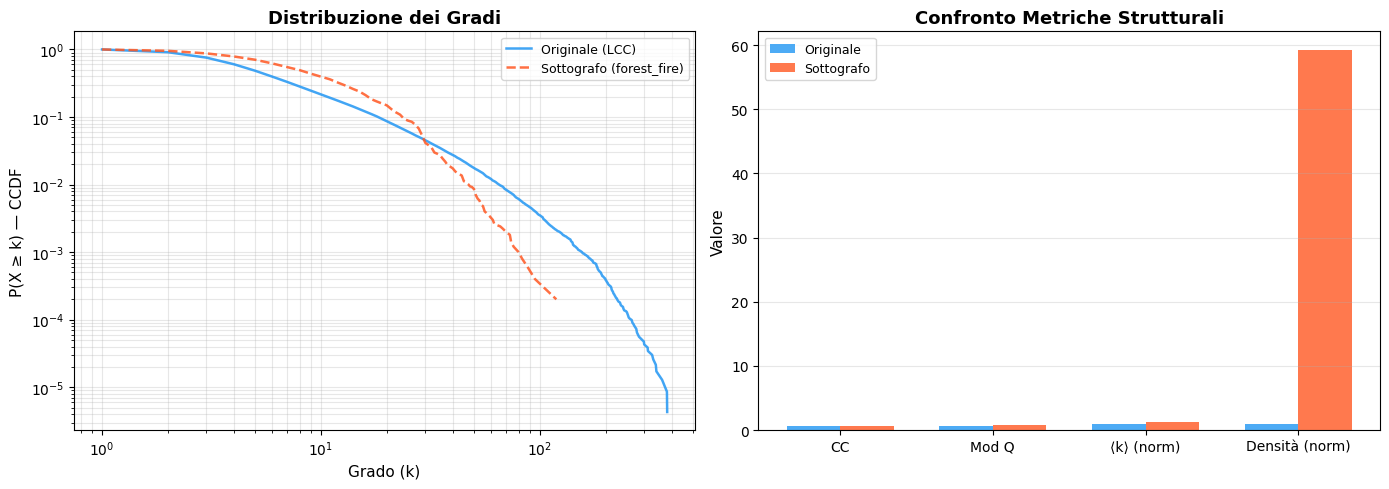

[Chart] Figura salvata: /kaggle/working/progetto/results/figures/subgraph_validation.png


In [12]:
# --- Validazione strutturale: sottografo vs originale ---
import time

def _quick_metrics(G, label, sample_size=3000):
    """Calcola metriche strutturali chiave per un grafo."""
    t0 = time.time()
    n = G.number_of_nodes()
    degrees = np.array([d for _, d in G.degree()])

    # Clustering (campionato per grafi grandi)
    if n > 10_000:
        sample_nodes = list(np.random.default_rng(42).choice(
            list(G.nodes()), size=min(sample_size, n), replace=False))
        cc = nx.average_clustering(G, nodes=sample_nodes)
    else:
        cc = nx.average_clustering(G)

    # Modularity (label propagation — veloce)
    comms = list(nx.community.label_propagation_communities(G))
    mod_q = nx.community.modularity(G, comms)

    elapsed = time.time() - t0
    return {
        'label': label, 'nodes': n, 'edges': G.number_of_edges(),
        'density': nx.density(G), 'avg_degree': float(degrees.mean()),
        'max_degree': int(degrees.max()), 'std_degree': float(degrees.std()),
        'clustering': cc, 'modularity': mod_q, 'n_communities': len(comms),
        'degree_seq': sorted(degrees, reverse=True), 'time': elapsed,
    }

print('[Pending] Calcolo metriche grafo originale (LCC)...')
# Prendi la LCC del grafo completo (gia' in memoria da Cell 13)
lcc_nodes = max(nx.connected_components(G_full), key=len)
G_lcc = G_full.subgraph(lcc_nodes)
m_full = _quick_metrics(G_lcc, 'Originale (LCC)')

print('[Pending] Calcolo metriche sottografo...')
m_sub = _quick_metrics(subG, f'Sottografo ({cfg.subgraph.strategy})')

# --- Tabella di confronto ---
print('\n' + '=' * 72)
print('VALIDAZIONE STRUTTURALE — Sottografo vs Originale')
print('=' * 72)
print(f'{"Metrica":<22} {"Originale":>14} {"Sottografo":>14} {"Δ relativo":>14}')
print('-' * 72)

comparisons = [
    ('Nodi',            'nodes',         '%d'),
    ('Archi',           'edges',         '%d'),
    ('Densità',         'density',       '%.6f'),
    ('Grado medio ⟨k⟩', 'avg_degree',   '%.1f'),
    ('Grado max',       'max_degree',    '%d'),
    ('σ(grado)',        'std_degree',    '%.1f'),
    ('Clustering CC',   'clustering',    '%.4f'),
    ('Modularity Q',    'modularity',    '%.4f'),
    ('N. comunità',     'n_communities', '%d'),
]

for label, key, fmt in comparisons:
    v_full = m_full[key]
    v_sub  = m_sub[key]
    if v_full != 0:
        delta_pct = (v_sub - v_full) / abs(v_full) * 100
        delta_s = f'{delta_pct:+.1f}%'
    else:
        delta_s = 'n/a'
    print(f'{label:<22} {fmt % v_full:>14} {fmt % v_sub:>14} {delta_s:>14}')

print('=' * 72)
ratio = m_sub['nodes'] / m_full['nodes'] * 100
print(f'Rapporto campionamento: {ratio:.1f}% dei nodi originali')
print(f'Tempo calcolo: originale={m_full["time"]:.1f}s, sottografo={m_sub["time"]:.1f}s')

# --- Plot: CCDF dei gradi ---
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Degree CCDF (log-log)
    ax = axes[0]
    for m, color, ls in [(m_full, '#2196F3', '-'), (m_sub, '#FF5722', '--')]:
        degs = np.array(m['degree_seq'])
        unique_d = np.sort(np.unique(degs))
        ccdf = np.array([np.mean(degs >= d) for d in unique_d])
        ax.loglog(unique_d, ccdf, ls, color=color, label=m['label'], linewidth=1.8, alpha=0.85)
    ax.set_xlabel('Grado (k)', fontsize=11)
    ax.set_ylabel('P(X ≥ k) — CCDF', fontsize=11)
    ax.set_title('Distribuzione dei Gradi', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

    # Panel 2: Bar chart metriche normalizzate
    ax = axes[1]
    metric_labels = ['CC', 'Mod Q', '⟨k⟩ (norm)', 'Densità (norm)']
    full_vals = [m_full['clustering'], m_full['modularity'], 1.0, 1.0]
    sub_vals = [
        m_sub['clustering'],
        m_sub['modularity'],
        m_sub['avg_degree'] / max(m_full['avg_degree'], 1e-8),
        m_sub['density'] / max(m_full['density'], 1e-8),
    ]
    x = np.arange(len(metric_labels))
    w = 0.35
    ax.bar(x - w/2, full_vals, w, label='Originale', color='#2196F3', alpha=0.8)
    ax.bar(x + w/2, sub_vals, w, label='Sottografo', color='#FF5722', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel('Valore', fontsize=11)
    ax.set_title('Confronto Metriche Strutturali', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fig_path = cfg.project_root / cfg.paths.figures / 'subgraph_validation.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[Chart] Figura salvata: {fig_path}')
except Exception as e:
    print(f'[Warning]️ Plot non disponibile: {e}')

In [13]:
# --- 3. Community detection ---
from src.graph.community import detect_communities, community_stats

print(f'[Pending] Community detection (algoritmo={cfg.community.algorithm})...')
community_map, n_comm, q = detect_communities(subG, cfg)
stats = community_stats(subG, community_map)
print(f'[Done] Community: {n_comm} trovate | Q={q:.4f}')
print(f'   Dimensioni: min={stats["min_size"]} max={stats["max_size"]} media={stats["mean_size"]:.1f}')

[Pending] Community detection (algoritmo=label_propagation)...


[07:39:28] INFO     [Community] Community detection con algoritmo='label_propagation'...

           INFO     [Community] Trovate 415 community | Q=0.8265

           INFO     [Community] Community map salvata: /kaggle/working/progetto/data/processed/community_map.json

[Done] Community: 415 trovate | Q=0.8265
   Dimensioni: min=2 max=128 media=12.0


In [14]:
# --- 4. Metriche baseline ---
from src.graph.metrics import compute_all_metrics, compute_centralities

print('[Pending] Calcolo metriche baseline...')
baseline_metrics = compute_all_metrics(subG, cfg, community_map=community_map)
centralities = compute_centralities(subG, cfg)

print('\n[Chart] METRICHE BASELINE (Fase 0)')
print('=' * 40)
for k, v in baseline_metrics.items():
    if isinstance(v, float):
        print(f'  {k:30s}: {v:.4f}')
    elif isinstance(v, int):
        print(f'  {k:30s}: {v:,}')

# Top-5 PageRank
top_pr = sorted(
    [(n, d.get('pagerank', 0)) for n, d in centralities.items()],
    key=lambda x: x[1], reverse=True
)[:5]
print(f'\n  Top-5 PageRank: {[(n, f"{pr:.4f}") for n, pr in top_pr]}')

[Pending] Calcolo metriche baseline...


           INFO     [Metrics] Connected components...

           INFO     [Metrics] Clustering coefficient (esatto)...

[07:39:29] INFO     [Metrics] Degree centrality (5000 nodi)...

           INFO     [Metrics] PageRank...

           INFO     [Metrics] Katz centrality (scipy sparse)...


[Chart] METRICHE BASELINE (Fase 0)
  num_nodes                     : 5,000
  num_edges                     : 26,246
  density                       : 0.0021
  avg_degree                    : 10.4984
  num_connected_components      : 1
  avg_clustering                : 0.6988
  max_degree                    : 119
  min_degree                    : 1
  std_degree                    : 9.7465
  modularity_q                  : 0.8265
  echo_chamber_index            : 0.8318

  Top-5 PageRank: [(3342, '0.0011'), (1316, '0.0009'), (505, '0.0009'), (3612, '0.0008'), (863, '0.0008')]


---
## Fase 1+2 — Agenti LLM e Co-evoluzione

L'**Orchestratore** gestisce l'intera pipeline:
1. Inizializza embeddings, NetworkManager, agenti LLM e pazienti zero
2. Esegue il loop co-evolutivo: **Agenti → GNN fine-tuning → Rewiring**
3. Salva checkpoint e metriche CSV ad ogni step

> [Agent] **LLM reale**: gli agenti usano il server vLLM locale (Llama 3 8B Instruct AWQ) per generare opinioni e transizioni di stato.
> Non viene usato nessun mock.

In [15]:
# ============================================================
# IMPORT CHECKPOINT DA VERSIONE PRECEDENTE (cross-session Kaggle)
# ============================================================
# Se PREV_VERSION_CKPT_INPUT e' impostato, copia il checkpoint
# dall'output della versione precedente nella directory checkpoints
# del progetto, cosi' RESUME_FROM_CKPT=True trovera' il file.
import shutil
from pathlib import Path

if RESUME_FROM_CKPT and PREV_VERSION_CKPT_INPUT is not None:
    src_ckpt = Path(PREV_VERSION_CKPT_INPUT)
    if not src_ckpt.exists():
        raise FileNotFoundError(f'Checkpoint non trovato: {src_ckpt}')
    ckpt_dir = PROJECT_ROOT / 'results' / 'checkpoints'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    dst = ckpt_dir / src_ckpt.name
    shutil.copy2(src_ckpt, dst)
    print(f'\u2705 Checkpoint importato: {src_ckpt.name} \u2192 {dst}')
elif RESUME_FROM_CKPT:
    # Controlla se esiste gia' un checkpoint locale
    ckpt_dir = PROJECT_ROOT / 'results' / 'checkpoints'
    existing = sorted(ckpt_dir.glob('ckpt_step_*.pkl')) if ckpt_dir.exists() else []
    if existing:
        print(f'\u2705 Checkpoint locale trovato: {existing[-1].name}')
    else:
        print('\u26a0\ufe0f  RESUME_FROM_CKPT=True ma nessun checkpoint trovato.')
        print('   Imposta PREV_VERSION_CKPT_INPUT per importare da versione precedente.')
        RESUME_FROM_CKPT = False  # fallback: nuova run
else:
    print('\u2139\ufe0f  Prima sessione, parto da zero.')

✅ Checkpoint importato: ckpt_step_0099.pkl → /kaggle/working/progetto/results/checkpoints/ckpt_step_0099.pkl


In [16]:
# ============================================================
# IMPORT CSV METRICHE DA VERSIONE PRECEDENTE
# ============================================================
# Se PREV_VERSION_CSV_INPUT e' impostato, copia il CSV dalla
# versione precedente nella directory results/ del progetto.
# L'orchestratore aprira' il CSV in append mode e accodera' i nuovi step,
# mantenendo la storia completa di tutte le sessioni.
import shutil
from pathlib import Path

results_dir = PROJECT_ROOT / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
csv_dst = results_dir / 'metrics_history.csv'

if RESUME_FROM_CKPT and PREV_VERSION_CSV_INPUT is not None:
    src_csv = Path(PREV_VERSION_CSV_INPUT)
    if src_csv.exists():
        shutil.copy2(src_csv, csv_dst)
        import pandas as pd
        df_prev = pd.read_csv(csv_dst)
        print(f'\u2705 CSV metriche importato: {src_csv.name}')
        print(f'   Righe precedenti: {len(df_prev)} step (step {df_prev["step"].min()}..{df_prev["step"].max()})')
    else:
        print(f'\u26a0\ufe0f  CSV non trovato: {src_csv} \u2014 si parte da zero.')
elif RESUME_FROM_CKPT and csv_dst.exists():
    import pandas as pd
    df_prev = pd.read_csv(csv_dst)
    print(f'\u2705 CSV locale trovato: {len(df_prev)} step precedenti')
else:
    print('\u2139\ufe0f  Nessun CSV precedente da importare (prima sessione).')

✅ CSV metriche importato: metrics_history.csv
   Righe precedenti: 100 step (step 0..99)


In [17]:
import uuid
from src.orchestrator import SimulationOrchestrator

print('[Pending] Costruzione SimulationOrchestrator...')
orch = SimulationOrchestrator.build_from_config(
    cfg,
    use_mock_llm=USE_MOCK_LLM,
    resume=RESUME_FROM_CKPT,
)
print(f'[Done] Orchestratore pronto')
print(f'   Nodi: {orch.network_manager.num_nodes}')
print(f'   Archi: {orch.network_manager.num_edges}')

[Pending] Costruzione SimulationOrchestrator...


[07:39:31] INFO     [Seed] Tutti i seed impostati a: 42

           INFO     [SimLogger] Logging su: /kaggle/working/progetto/results/logs/phase2_76f14772.jsonl            
                    (run_id=76f14772)

           INFO     [Embeddings] Caricati da: /kaggle/working/progetto/data/processed/embeddings.npy | shape:      
                    (5000, 128)

           INFO     [Metrics] Degree centrality (5000 nodi)...

...

           INFO     [Orchestrator] Resume dal step 100 (ultimo checkpoint: step 99).

[07:39:35] INFO     [LLMClient] Local backend: casperhansen/llama-3-8b-instruct-awq

           INFO     [Orchestrator] Config hash: file=6d005e4774f8 | effettivo=75823ba4bd20

           INFO     [SimLogger] Run avviata — config_hash=6d005e4774f8

[Done] Orchestratore pronto
   Nodi: 5000
   Archi: 26246


In [18]:
# Tracking metriche per step (per i grafici finali)
metrics_history = []

# --- Resume: calcola il range corretto ---
# orch.resume_step = 0 se nuova run, = ckpt_step+1 se resume
start_step = orch.resume_step
end_step   = start_step + PHASE2_STEPS

print(f'\U0001f680 Avvio loop co-evolutivo: step {start_step} \u2192 {end_step - 1} ({PHASE2_STEPS} step questa sessione)...')
print(f'   (PHASE2_STEPS conta gli step di QUESTA sessione, non il totale)')
print('=' * 65)
print(f'{"Step":>5}  {"S":>6}  {"I":>6}  {"R":>6}  {"F":>6}  {"ECI":>8}  {"Loss":>8}  {"Edges":>7}  {"LLM":>5}  {"FB":>4}  {"Score min-max":>13}')
print('-' * 95)

for t in range(start_step, end_step):
    step_metrics = orch._run_step(t)
    s_counts = orch.state_summary
    metrics_history.append({'step': t, **step_metrics, **s_counts})

    print(
        f'{t:>5}  {s_counts.get("S",0):>6}  {s_counts.get("I",0):>6}  '
        f'{s_counts.get("R",0):>6}  {s_counts.get("F",0):>6}  '
        f'{step_metrics.get("echo_chamber_index") or 0.0:>8.4f}  '
        f'{step_metrics.get("gnn_loss") or 0.0:>8.4f}  '
        f'{step_metrics.get("num_edges") or 0:>7}  '
        # Chiamate LLM, risposte di fallback e intervallo degli score del GNN
        f'{step_metrics.get("llm_calls", 0):>5}  {step_metrics.get("llm_fallbacks", 0):>4}  '
        f'{step_metrics.get("gnn_score_min", 0.0):>6.3f}-{step_metrics.get("gnn_score_max", 0.0):<6.3f}'
    )

print('=' * 95)
print(f'\u2705 Loop completato. Step eseguiti: {start_step}\u2013{end_step - 1}')
print(f'   Ultimo checkpoint automatico: ckpt_step_{orch.current_step:04d}.pkl')

🚀 Avvio loop co-evolutivo: step 100 → 99 (0 step questa sessione)...
   (PHASE2_STEPS conta gli step di QUESTA sessione, non il totale)
 Step       S       I       R       F       ECI      Loss    Edges    LLM    FB  Score min-max
-----------------------------------------------------------------------------------------------
✅ Loop completato. Step eseguiti: 100–99
   Ultimo checkpoint automatico: ckpt_step_0100.pkl


In [19]:
# Chiudi il file CSV delle metriche in modo pulito
orch.close()
print('\u2705 Orchestratore chiuso (CSV metriche flushed).')

✅ Orchestratore chiuso (CSV metriche flushed).


[Chart] Grafico salvato: /kaggle/working/progetto/results/figures/phase2_evolution.png


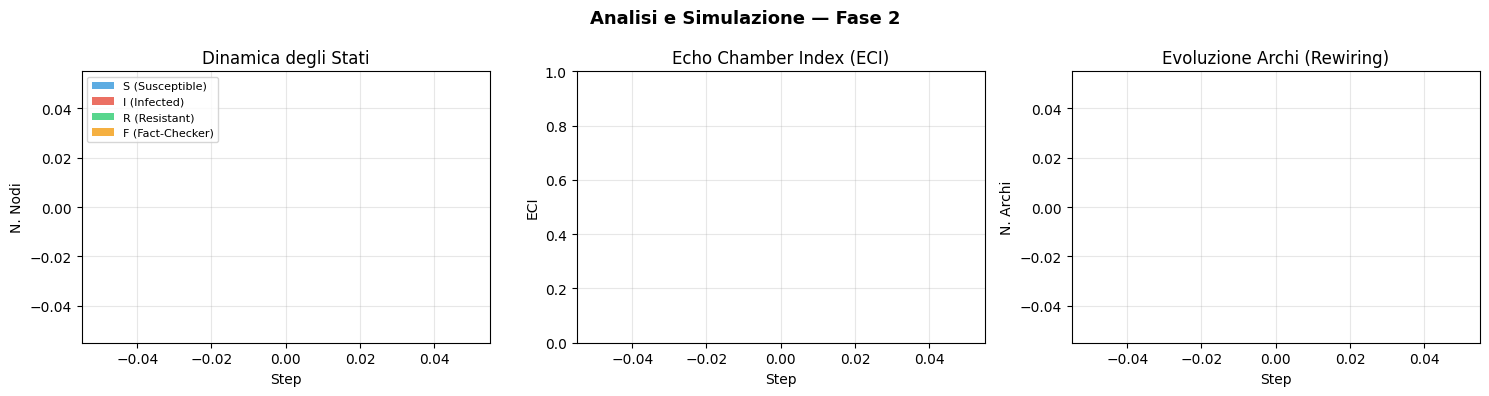

In [20]:
# Visualizzazione evoluzione nel tempo
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    steps = [m['step'] for m in metrics_history]
    n_S = [m.get('S', 0) for m in metrics_history]
    n_I = [m.get('I', 0) for m in metrics_history]
    n_R = [m.get('R', 0) for m in metrics_history]
    n_F = [m.get('F', 0) for m in metrics_history]
    eci = [m.get('echo_chamber_index') or 0.0 for m in metrics_history]
    loss= [m.get('gnn_loss') or 0.0 for m in metrics_history]
    edges=[m.get('num_edges') or 0 for m in metrics_history]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Analisi e Simulazione — Fase 2', fontsize=13, fontweight='bold')
    
    # Plot 1: Dinamica stati
    axes[0].stackplot(steps, n_S, n_I, n_R, n_F,
                      labels=['S (Susceptible)', 'I (Infected)', 'R (Resistant)', 'F (Fact-Checker)'],
                      colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.8)
    axes[0].set_title('Dinamica degli Stati')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('N. Nodi')
    axes[0].legend(loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Echo Chamber Index
    axes[1].plot(steps, eci, color='#8e44ad', linewidth=2, marker='o', markersize=4)
    axes[1].fill_between(steps, eci, alpha=0.2, color='#8e44ad')
    axes[1].set_title('Echo Chamber Index (ECI)')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('ECI')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)
    
    # Plot 3: Archi nel tempo (rewiring)
    axes[2].plot(steps, edges, color='#16a085', linewidth=2, marker='s', markersize=4)
    axes[2].fill_between(steps, edges, alpha=0.2, color='#16a085')
    axes[2].set_title('Evoluzione Archi (Rewiring)')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('N. Archi')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    fig_path = cfg.project_root / cfg.paths.figures / 'phase2_evolution.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'[Chart] Grafico salvato: {fig_path}')
    plt.show()

except ImportError:
    print('matplotlib non disponibile — skip grafici')

---
## Fase 3 — CELF Fact-Checking

Selezione ottimale dei seed fact-checker tramite **CELF** (Cost-Effective Lazy Forward), iniezione e misurazione dell'impatto.

**Flusso:**
1. Snapshot metriche pre-intervento (baseline)
2. CELF seleziona i `k` nodi ottimali per massimizzare lo spread fact-checking
3. Iniezione: i nodi selezionati diventano Fact-Checker (stato F)
4. N step post-intervento per osservare la propagazione
5. Confronto before/after con delta metriche

> [Chart] Il CSV include una colonna `phase` per distinguere step Fase 2 da Fase 3.

In [21]:
from src.graph.metrics import compute_all_metrics
from src.agents.state_machine import StateMachine

# Snapshot pre-intervento
nm_ph3 = orch.network_manager
community_map_ph3 = nm_ph3._community_map

pre_belief_map = nm_ph3.get_belief_map()
pre_metrics = compute_all_metrics(nm_ph3.G, cfg, community_map_ph3, pre_belief_map)
pre_states = nm_ph3.get_all_states()
pre_counts = StateMachine.count_states(pre_states)
n_total = max(nm_ph3.num_nodes, 1)
pre_metrics['infection_rate'] = pre_counts['I'] / n_total
pre_metrics['n_S'] = pre_counts['S']
pre_metrics['n_I'] = pre_counts['I']
pre_metrics['n_R'] = pre_counts['R']
pre_metrics['n_F'] = pre_counts['F']

print('[Chart] BASELINE PRE-INTERVENTO')
print(f'  S={pre_counts["S"]}  I={pre_counts["I"]}  R={pre_counts["R"]}  F={pre_counts["F"]}')
print(f'  Infection Rate : {pre_metrics["infection_rate"]:.4f}')
print(f'  ECI            : {pre_metrics.get("echo_chamber_index") or 0.0:.4f}')
print(f'  Modularity Q   : {pre_metrics.get("modularity_q") or 0.0:.4f}')

[07:39:37] INFO     [Metrics] Connected components...

           INFO     [Metrics] Clustering coefficient (esatto)...

[Chart] BASELINE PRE-INTERVENTO
  S=978  I=2032  R=1990  F=0
  Infection Rate : 0.4064
  ECI            : 0.8741
  Modularity Q   : 0.8769


In [22]:
# --- CELF: selezione seed ---
from src.influence.celf import CELF
from src.influence.injector import FactCheckerInjector

injector = FactCheckerInjector(cfg)
celf_seeds, estimated_spread = [], 0.0
injection_forced = False

if PHASE3_STEPS == 0:
    print('[Skip] PHASE3_STEPS = 0: sessione intermedia di Fase 2, niente CELF ne\' iniezione.')
elif CONTROL_RUN:
    print('[Skip] CONTROL_RUN = True: nessun fact-checker (scenario di controllo).')
else:
    # Soglia di attivazione (cfg.influence.activation_threshold)
    rate_now = pre_metrics['infection_rate']
    thr = cfg.influence.activation_threshold
    if rate_now < thr:
        if FORCE_INJECTION:
            injection_forced = True
            print(f'[Warn] infection_rate={rate_now:.4f} < activation_threshold={thr}: '
                  f'iniezione FORZATA (FORCE_INJECTION = True).')
        else:
            print(f'[Skip] infection_rate={rate_now:.4f} < activation_threshold={thr}: '
                  f'nessuna iniezione (imposta FORCE_INJECTION = True per forzarla).')
    if rate_now >= thr or FORCE_INJECTION:
        print(f'[Pending] CELF ({cfg.influence.celf_objective}): selezione {CELF_BUDGET_K} seed fact-checker...')
        celf = CELF(cfg)
        celf_seeds = celf.select(
            graph=nm_ph3.G,
            budget_k=CELF_BUDGET_K,
            agent_states=nm_ph3.get_all_states(),
        )
        print(f'[Done] CELF seeds: {celf_seeds}')
        estimated_spread = celf.estimate_spread(nm_ph3.G, celf_seeds, nm_ph3.get_all_states())
        print(f'   Nodi coperti stimati: {estimated_spread:.1f} ({estimated_spread/n_total*100:.1f}%)')


[Skip] CONTROL_RUN = True: nessun fact-checker (scenario di controllo).


In [23]:
# --- Iniezione fact-checker ---
injected = []
if celf_seeds:
    injected = injector.inject(nm_ph3, celf_seeds, step=orch.next_step)
    print(f'[Done] Fact-checker iniettati: {len(injected)} nodi → {injected}')
    # Allinea lo stato interno degli agenti al grafo (nodi iniettati -> F)
    n_sync = orch.sync_agent_states(injected)
    print(f'   Agenti sincronizzati: {n_sync}')
else:
    print('[Skip] Nessun fact-checker iniettato.')


[Skip] Nessun fact-checker iniettato.


In [24]:
# --- Step post-intervento ---
print(f'[Pending] Esecuzione {PHASE3_STEPS} step post-intervento...')
post_history = []

# Marca i prossimi step nel CSV: "3" = intervento, "3_control" = controllo
orch._phase = "3_control" if CONTROL_RUN else "3"
if PHASE3_STEPS == 0:
    print("[Info] PHASE3_STEPS = 0: nessuno step di Fase 3 in questa sessione.")

# FIX: next_step e' il primo step non ancora eseguito (prima +1 saltava uno step)
start_step = orch.next_step
for t in range(start_step, start_step + PHASE3_STEPS):
    step_metrics = orch._run_step(t)
    s_counts = orch.state_summary
    post_history.append({'step': t, **step_metrics, **s_counts})
    print(
        f'  Step {t}: S={s_counts.get("S",0)} I={s_counts.get("I",0)} '
        f'R={s_counts.get("R",0)} F={s_counts.get("F",0)} '
        f'ECI={step_metrics.get("echo_chamber_index") or 0.0:.4f} '
        f'Assort={step_metrics.get("belief_assortativity") or 0.0:.4f}'
    )

print('[Done] Step post-intervento completati')

[Pending] Esecuzione 30 step post-intervento...


[07:39:39] INFO     [Orchestrator] Stocastico: attivati 750 nodi su 5000 (15.0%)

[07:46:39] INFO     [Orchestrator] Attendendo completamento di 616 chiamate LLM...

           INFO     [Orchestrator] [LLM Response Example] Agent 2018: {                                            
                      "reasoning": "The posts from my colleagues all agree on the importance of echo chamber       
                    polarization. I'm starting to feel convinced too.",                                            
                      "opinion": "I'm still convinced that echo chamber polarization is real! Let's keep discussing
                    the nuances! #echo_chamber_polarization",                                                      
                      "susceptibility": 0.6,                                                                       
                      "proposed_state": "I",                                                                       
                      "spread_intent": true                                                                        
                    }

           INFO     [StateMachine] Nodo 3306: S -> R (active_resistance (f_I=0.14 >= 0.12, susc=0.40 < 0.50))

...

           INFO     [Orchestrator] [LLM Response Example] Agent 1671: {                                            
                      "reasoning": "I'm heartened to see so many colleagues on the same page, prioritizing         
                    scientific research and evidence-based solutions. This reinforces my own stance and gives me   
                    confidence in the consensus.",                                                                 
                      "opinion": "I'm glad we're in agreement on prioritizing scientific research! Let's keep      
                    focusing on concrete evidence.",                                                               
                      "susceptibility": 0.0,                                                                       
                      "proposed_state": "R",                                                                       
                      "spread_intent": false                                                                       
                    }

           INFO     [Orchestrator] [LLM Response Example] Agent 3506: {                                            
                      "reasoning": "The majority of my colleagues are convinced, and their enthusiasm is           
                    contagious. I feel compelled to join the movement and spread the truth.",                      
                      "opinion": "Let's keep spreading the truth! We must work together to expose                  
                    echo_chamber_polarization! #echo_chamber_polarization",                                        
                      "susceptibility": 0.9,                                                                       
                      "proposed_state": "I",                                                                       
                      "spread_intent": true                                                                        
                    }

[11:11:33] INFO       States: S=974 I=2024 R=2002 F=0 | Rewire: +0 -0 | ECI=0.886 | Assort=0.692 | Loss=0.3643 |   
                    LLM: 629 chiamate, 0 fallback | score archi [0.278, 0.990]

           INFO     [Checkpoint] Salvato: ckpt_step_0129.pkl (step=129)

  Step 129: S=974 I=2024 R=2002 F=0 ECI=0.8858 Assort=0.6922
[Done] Step post-intervento completati


In [25]:
# --- Report completo ---
from src.influence.metrics import compute_full_influence_report

final_report = compute_full_influence_report(
    G=nm_ph3.G,
    agent_states=nm_ph3.get_all_states(),
    community_map=community_map_ph3,
    baseline_metrics=pre_metrics,
    cfg=cfg,
)
final_report['control_run'] = CONTROL_RUN
final_report['injection_forced'] = injection_forced
final_report['celf_objective'] = cfg.influence.celf_objective
final_report['celf_seeds'] = celf_seeds
final_report['estimated_covered_nodes'] = estimated_spread
final_report['injected_nodes'] = list(injected)
final_report['phase3_start_step'] = start_step
final_report['phase3_end_step'] = orch.next_step - 1
final_report['n_post_steps'] = PHASE3_STEPS
final_report['sampling_strategy'] = cfg.subgraph.strategy
final_report['forward_prob'] = cfg.subgraph.forward_prob

print('\n' + '=' * 65)
print('CONFRONTO BEFORE / AFTER ' + ('(RUN DI CONTROLLO, senza fact-checker)' if CONTROL_RUN else 'INTERVENTO CELF'))
print('=' * 65)
print(f'{"Metrica":<25}  {"PRIMA":>10}  {"DOPO":>10}  {"DELTA":>10}')
print('-' * 65)

metrics_to_compare = [
    ('Infection Rate',      'infection_rate',       '%.4f'),
    ('Echo Chamber Idx',    'echo_chamber_index',   '%.4f'),
    ('Modularity Q',        'modularity_q',         '%.4f'),
    ('Belief Polarisation', 'belief_polarisation',  '%.4f'),
    ('Opinion Homophily',   'opinion_homophily',    '%.4f'),
    ('Belief Assortativity','belief_assortativity', '%.4f'),
    ('Nodi S',              'n_S',                  '%d'),
    ('Nodi I',              'n_I',                  '%d'),
    ('Nodi R',              'n_R',                  '%d'),
    ('Nodi F',              'n_F',                  '%d'),
]

for label, key, fmt in metrics_to_compare:
    before = pre_metrics.get(key)
    after  = final_report.get(key)
    delta  = final_report.get(f'delta_{key}')
    before_s = (fmt % before) if before is not None else 'n/a'
    after_s  = (fmt % after)  if after  is not None else 'n/a'
    delta_s  = (f'{delta:+.4f}' if isinstance(delta, float) else
                f'{delta:+d}' if isinstance(delta, int) else 'n/a')
    print(f'{label:<25}  {before_s:>10}  {after_s:>10}  {delta_s:>10}')

print('-' * 65)
print(f'{"FC Reach (entro reach_hops)":<25}  {"":>10}  {final_report.get("fcs", 0.0):>10.4f}')
print(f'{"FC Copertura efficace":<25}  {"":>10}  {final_report.get("fc_effective_coverage", 0.0):>10.4f}')
print(f'{"Avg Reach per FC":<25}  {"":>10}  {final_report.get("avg_reach_per_fc", 0.0):>10.1f}')
print('=' * 65)

# --- Salva report JSON ---
import json
report_name = 'phase3_report_control.json' if CONTROL_RUN else 'phase3_report.json'
report_path = cfg.project_root / cfg.paths.results / report_name
serializable = {k: v for k, v in final_report.items()
                if isinstance(v, (int, float, str, list, dict, bool, type(None)))}
with open(report_path, 'w') as f:
    json.dump(serializable, f, indent=2)
print(f'\n[Save] Report salvato: {report_path}')

[11:11:34] INFO     [InfluenceMetrics] Report: infection_rate=0.405 | ECI=0.886 | FCS=0.000 |                      
                    delta_infection=-0.002 | n_F=0


CONFRONTO BEFORE / AFTER (RUN DI CONTROLLO, senza fact-checker)
Metrica                         PRIMA        DOPO       DELTA
-----------------------------------------------------------------
Infection Rate                 0.4064      0.4048     -0.0016
Echo Chamber Idx               0.8741      0.8858     +0.0117
Modularity Q                   0.8769      0.8835     +0.0066
Belief Polarisation            0.8043      0.8052     +0.0009
Opinion Homophily              0.8140      0.8306     +0.0167
Belief Assortativity           0.6586      0.6922     +0.0336
Nodi S                            978         974     -4.0000
Nodi I                           2032        2024     -8.0000
Nodi R                           1990        2002    +12.0000
Nodi F                              0           0     +0.0000
-----------------------------------------------------------------
FC Reach (entro reach_hops)                  0.0000
FC Copertura efficace                      0.0000
Avg Reach per FC   

[Chart] Grafico salvato: /kaggle/working/progetto/results/figures/phase3_control.png


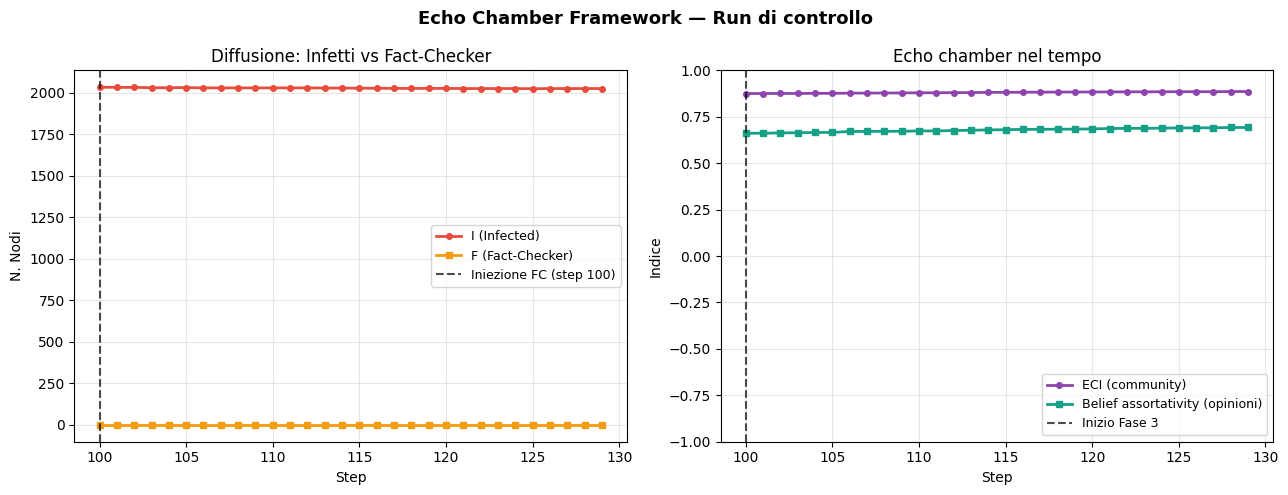

In [26]:
# --- Visualizzazione Phase 3 ---
try:
    import matplotlib.pyplot as plt
    
    # Combina metriche storia completa
    all_history = metrics_history + post_history
    all_steps = [m['step'] for m in all_history]
    all_n_I = [m.get('I', m.get('n_I', 0)) for m in all_history]
    all_n_F = [m.get('F', m.get('n_F', 0)) for m in all_history]
    all_eci = [m.get('echo_chamber_index') or 0.0 for m in all_history]
    all_assort = [m.get('belief_assortativity') or 0.0 for m in all_history]
    
    injection_step = start_step
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Echo Chamber Framework — ' + ('Run di controllo' if CONTROL_RUN else 'Intervento CELF'), fontsize=13, fontweight='bold')
    
    # Plot: Nodi I e F nel tempo
    ax1.plot(all_steps, all_n_I, color='#e74c3c', linewidth=2, label='I (Infected)', marker='o', ms=4)
    ax1.plot(all_steps, all_n_F, color='#f39c12', linewidth=2, label='F (Fact-Checker)', marker='s', ms=4)
    ax1.axvline(x=injection_step, color='black', linestyle='--', alpha=0.7, label=f'Iniezione FC (step {injection_step})')
    ax1.set_title('Diffusione: Infetti vs Fact-Checker')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('N. Nodi')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot: ECI nel tempo
    ax2.plot(all_steps, all_eci, color='#8e44ad', linewidth=2, marker='o', ms=4, label='ECI (community)')
    ax2.plot(all_steps, all_assort, color='#16a085', linewidth=2, marker='s', ms=4, label='Belief assortativity (opinioni)')
    ax2.axvline(x=injection_step, color='black', linestyle='--', alpha=0.7, label='Inizio Fase 3')
    ax2.set_title('Echo chamber nel tempo')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Indice')
    ax2.set_ylim(-1, 1)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    fig_path = cfg.project_root / cfg.paths.figures / ('phase3_control.png' if CONTROL_RUN else 'phase3_intervention.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'[Chart] Grafico salvato: {fig_path}')
    plt.show()

except ImportError:
    print('matplotlib non disponibile — skip grafici')

---
## Riepilogo Pipeline

In [27]:
import json

pipeline_summary = {
    'config_hash': cfg.config_hash,
    'seed': cfg.execution.random_seed,
    'phase0': {
        'n_nodes': subG.number_of_nodes(),
        'n_edges': subG.number_of_edges(),
        'n_communities': n_comm,
        'modularity_q_baseline': round(q, 4),
        'echo_chamber_index_baseline': round(baseline_metrics.get('echo_chamber_index') or 0.0, 4),
    },
    'phase1': {
        'n_patient_zeros': len(orch._patient_zero_ids),
        'patient_zero_ids': orch._patient_zero_ids,
        'strategy': cfg.simulation.seeder_strategy,
    },
    'phase2': {
        # Step totali di Fase 2 su tutte le sessioni (= primo step di Fase 3)
        'n_steps_total': start_step,
        'n_steps_this_session': PHASE2_STEPS,
        'llm_mode': 'mock' if USE_MOCK_LLM else cfg.llm.backend,
        'llm_model': 'mock' if USE_MOCK_LLM else (
            cfg.llm.local.model if cfg.llm.backend == 'local' else cfg.llm.api.model),
        'final_state_counts': pre_counts,
        'infection_rate_post_phase2': round(pre_metrics['infection_rate'], 4),
        'eci_post_phase2': round(pre_metrics.get('echo_chamber_index') or 0.0, 4),
    },
    'phase3': {
        'control_run': CONTROL_RUN,
        'celf_objective': cfg.influence.celf_objective,
        'celf_seeds': celf_seeds,
        'injected_nodes': injected,
        'budget_k': CELF_BUDGET_K,
        'n_post_steps': PHASE3_STEPS,
        'fcs_reach': round(final_report.get('fcs', 0.0), 4),
        'fc_effective_coverage': round(final_report.get('fc_effective_coverage', 0.0), 4),
        'delta_infection_rate': round(final_report.get('delta_infection_rate', 0.0), 4),
        'delta_eci': round(final_report.get('delta_echo_chamber_index', 0.0), 4),
        'final_n_F': final_report.get('n_F', 0),
    },
}

summary_path = cfg.project_root / cfg.paths.results / (
    'pipeline_summary_control.json' if CONTROL_RUN else 'pipeline_summary.json')
with open(summary_path, 'w') as f:
    json.dump(pipeline_summary, f, indent=2)

print('\n' + '=' * 60)
print('PIPELINE COMPLETATA [Done]')
print('=' * 60)
print(f'  Nodi simulati    : {subG.number_of_nodes()}')
print(f'  Archi iniziali   : {subG.number_of_edges()}')
print(f'  Community        : {n_comm} (Q baseline={q:.4f})')
print(f'  Step Fase 2      : {start_step} totali ({PHASE2_STEPS} in questa sessione)')
print(f'  LLM              : {pipeline_summary["phase2"]["llm_model"]}')
print(f'  Infection rate   : {pre_metrics["infection_rate"]:.4f} → {final_report.get("infection_rate", 0.0):.4f}')
print(f'  ECI              : {pre_metrics.get("echo_chamber_index") or 0.0:.4f} → {final_report.get("echo_chamber_index") or 0.0:.4f}')
print(f'  CELF seeds       : {len(celf_seeds)} nodi')
print(f'  Run di controllo : {CONTROL_RUN}')
print(f'  FC copertura eff.: {final_report.get("fc_effective_coverage", 0.0):.4f}')
print('=' * 60)
print(f'Riepilogo salvato: {summary_path}')


PIPELINE COMPLETATA [Done]
  Nodi simulati    : 5000
  Archi iniziali   : 26246
  Community        : 415 (Q baseline=0.8265)
  Step Fase 2      : 100 totali (0 in questa sessione)
  LLM              : casperhansen/llama-3-8b-instruct-awq
  Infection rate   : 0.4064 → 0.4048
  ECI              : 0.8741 → 0.8858
  CELF seeds       : 0 nodi
  Run di controllo : True
  FC copertura eff.: 0.0000
Riepilogo salvato: /kaggle/working/progetto/results/pipeline_summary_control.json


## Visualizzazione Finale: Come è cambiata la Rete
Esegue un confronto visuale tra la struttura della rete all'inizio della simulazione e la struttura alla fine dell'ultimo step, campionando i nodi principali per mantenere il grafico leggibile.

Generazione del grafico riassuntivo in corso...


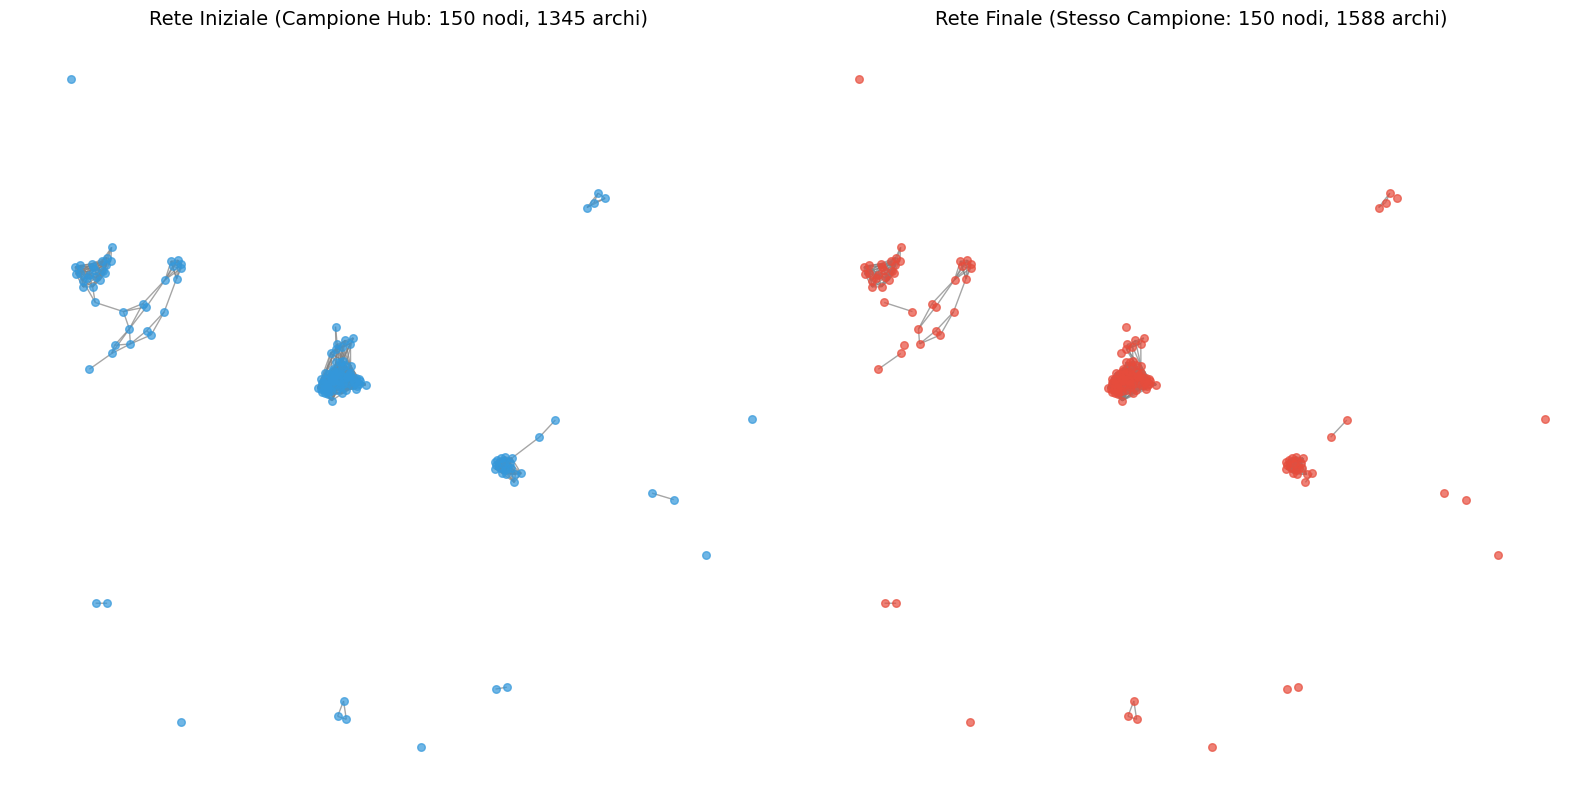

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import glob
import os

# ---------------------------------------------------------
# VISUALIZZAZIONE RIASSUNTIVA: RETE INIZIALE VS RETE FINALE
# ---------------------------------------------------------
print("Generazione del grafico riassuntivo in corso...")

# 1. Carica il grafo iniziale
init_path = 'data/processed/subgraph.gpickle'
if os.path.exists(init_path):
    with open(init_path, 'rb') as f:
        data = pickle.load(f)
    G_init = data['graph'] if isinstance(data, dict) else data
else:
    print("Grafo iniziale non trovato.")
    G_init = None

# 2. Carica l'ultimo checkpoint per la rete finale
checkpoints = sorted(glob.glob('results/checkpoints/ckpt_step_*.pkl'))
if checkpoints and G_init:
    last_ckpt = checkpoints[-1]
    with open(last_ckpt, 'rb') as f:
        ckpt_data = pickle.load(f)
    
    # Estrai il grafo finale dal NetworkManager salvato
    G_final = ckpt_data.graph_payload["graph"]

    # Campionamento: visualizzare 30k nodi creerebbe una macchia nera.
    # Selezioniamo un campione dei 150 nodi più connessi (hub)
    degrees = dict(G_init.degree())
    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:150]
    
    # Estrai i sottografi per il campione
    sub_init = G_init.subgraph(top_nodes)
    sub_final = G_final.subgraph(top_nodes)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Fissa il layout in base al grafo iniziale per poter confrontare visivamente
    pos = nx.spring_layout(sub_init, seed=42)
    
    # Disegna Rete Iniziale
    nx.draw(sub_init, pos, ax=ax1, node_size=30, node_color='#3498db', edge_color='gray', alpha=0.7)
    ax1.set_title(f"Rete Iniziale (Campione Hub: {sub_init.number_of_nodes()} nodi, {sub_init.number_of_edges()} archi)", fontsize=14, pad=15)
    
    # Disegna Rete Finale
    nx.draw(sub_final, pos, ax=ax2, node_size=30, node_color='#e74c3c', edge_color='gray', alpha=0.7)
    ax2.set_title(f"Rete Finale (Stesso Campione: {sub_final.number_of_nodes()} nodi, {sub_final.number_of_edges()} archi)", fontsize=14, pad=15)
    
    plt.tight_layout()
    os.makedirs('results/figures', exist_ok=True)
    plt.savefig('results/figures/network_comparison_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Impossibile caricare i dati per il confronto. Verifica che la simulazione abbia salvato i checkpoint.")


---
## Confronto Intervento vs Controllo (Fase 3)

Da eseguire dopo entrambe le run di Fase 3 (con fact-checker e `CONTROL_RUN = True`), partite dallo stesso checkpoint finale di Fase 2. La cella cerca `phase3_report.json`, `phase3_report_control.json` e i `metrics_history*.csv` in `results/` e, su Kaggle, in `/kaggle/input`: nella sessione di controllo aggiungi come input l'output della sessione con intervento. Salva `results/phase3_comparison.json` e `results/figures/phase3_comparison.png`.

Intervento: /kaggle/input/datasets/io190901/checksnm/progetto/results/phase3_report.json
Controllo : /kaggle/working/progetto/results/phase3_report_control.json
[Warn] Step diversi: intervento=0 controllo=30. Confronto non valido.

EFFETTO DELL'INTERVENTO (intervento - controllo, a fine Fase 3)
Metrica                     Intervento     Controllo       Effetto
------------------------------------------------------------------------
Infection rate                  0.4064        0.4048       +0.0016
Nodi S                        978.0000      974.0000       +4.0000
Nodi I                       2032.0000     2024.0000       +8.0000
Nodi R                       1990.0000     2002.0000      -12.0000
Nodi F                          0.0000        0.0000       +0.0000
Echo Chamber Index              0.8741        0.8858       -0.0117
Modularity Q                    0.8769        0.8835       -0.0066
Belief polarisation             0.8043        0.8052       -0.0009
Opinion homophily           

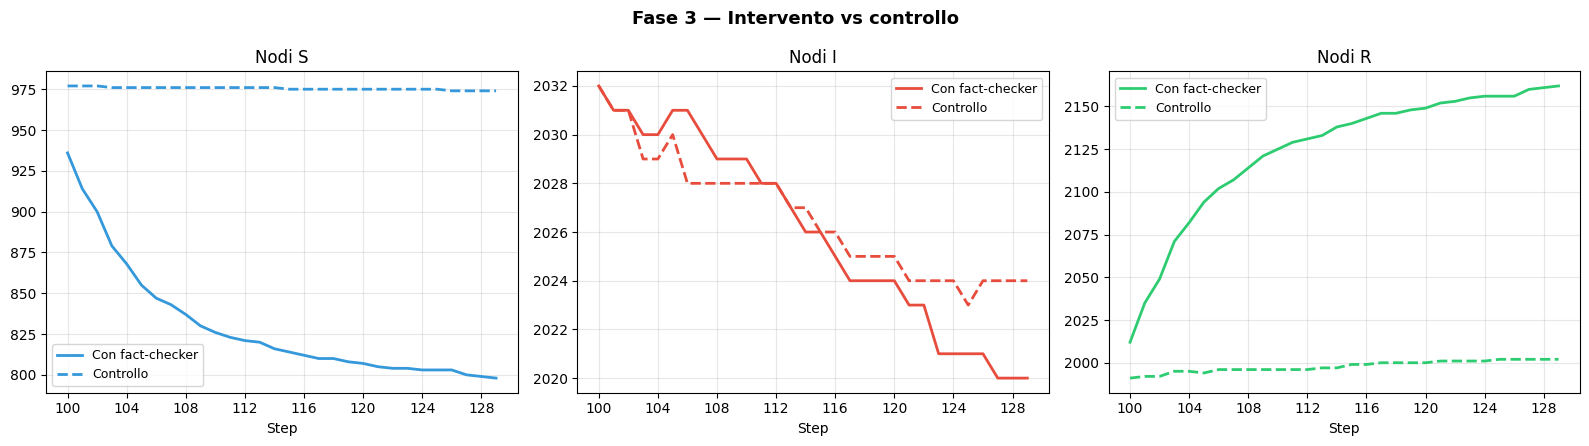

[Save] Confronto salvato: /kaggle/working/progetto/results/phase3_comparison.json


In [29]:
# --- Confronto intervento vs controllo (Fase 3) ---
# Cerca i report e i CSV delle due run in results/ e, su Kaggle, negli input
# (/kaggle/input: aggiungi come input l'output della sessione con l'altra run).
import csv, json
from pathlib import Path

search_dirs = [cfg.project_root / cfg.paths.results]
if Path('/kaggle/input').exists():
    search_dirs.append(Path('/kaggle/input'))

def _find(name):
    for d in search_dirs:
        hits = [d / name] if (d / name).exists() else sorted(d.rglob(name))
        if hits:
            return hits[0]
    return None

def _phase_rows(phase):
    """Righe del CSV con la fase indicata, da tutti i metrics_history*.csv trovati (per step)."""
    rows = {}
    for d in search_dirs:
        for p in sorted(d.rglob('metrics_history*.csv')):
            with open(p, newline='', encoding='utf-8') as f:
                for r in csv.DictReader(f):
                    if r.get('phase') == phase:
                        rows[int(r['step'])] = r
    return rows

treat_path = _find('phase3_report.json')
ctrl_path = _find('phase3_report_control.json')

if treat_path is None or ctrl_path is None:
    print('[Skip] Servono entrambi i report:')
    print(f'   intervento (phase3_report.json)         : {treat_path or "NON TROVATO"}')
    print(f'   controllo  (phase3_report_control.json) : {ctrl_path or "NON TROVATO"}')
    print('   Su Kaggle aggiungi come input l\'output della sessione con l\'altra run e riesegui questa cella.')
else:
    treat = json.load(open(treat_path, encoding='utf-8'))
    ctrl = json.load(open(ctrl_path, encoding='utf-8'))
    print(f'Intervento: {treat_path}')
    print(f'Controllo : {ctrl_path}')

    # --- Controlli di validita' del confronto ---
    if treat.get('control_run') or not ctrl.get('control_run'):
        print('[Warn] I file sembrano scambiati: control_run dovrebbe essere False per l\'intervento e True per il controllo.')
    if treat.get('n_post_steps') != ctrl.get('n_post_steps'):
        print(f'[Warn] Step diversi: intervento={treat.get("n_post_steps")} controllo={ctrl.get("n_post_steps")}. Confronto non valido.')
    if treat.get('phase3_start_step') != ctrl.get('phase3_start_step'):
        print(f'[Warn] Step di partenza diversi: {treat.get("phase3_start_step")} vs {ctrl.get("phase3_start_step")}.')
    # Stato di partenza = valore finale - delta: deve coincidere (stesso checkpoint)
    for key in ('n_S', 'n_I', 'n_R'):
        b_t = treat.get(key, 0) - treat.get(f'delta_{key}', 0)
        b_c = ctrl.get(key, 0) - ctrl.get(f'delta_{key}', 0)
        if abs(b_t - b_c) > 1e-9:
            print(f'[Warn] Stato iniziale diverso su {key}: {b_t:g} vs {b_c:g}. Le run non partono dallo stesso checkpoint.')

    # --- Effetto finale ---
    METRICS = [
        ('Infection rate',       'infection_rate'),
        ('Nodi S',               'n_S'),
        ('Nodi I',               'n_I'),
        ('Nodi R',               'n_R'),
        ('Nodi F',               'n_F'),
        ('Echo Chamber Index',   'echo_chamber_index'),
        ('Modularity Q',         'modularity_q'),
        ('Belief polarisation',  'belief_polarisation'),
        ('Opinion homophily',    'opinion_homophily'),
        ('Belief assortativity', 'belief_assortativity'),
    ]
    comparison = {'finale': {}}
    print('\n' + '=' * 72)
    print('EFFETTO DELL\'INTERVENTO (intervento - controllo, a fine Fase 3)')
    print('=' * 72)
    print(f'{"Metrica":<24}{"Intervento":>14}{"Controllo":>14}{"Effetto":>14}')
    print('-' * 72)
    for label, key in METRICS:
        t, c = treat.get(key), ctrl.get(key)
        if isinstance(t, (int, float)) and isinstance(c, (int, float)):
            comparison['finale'][key] = {'intervento': t, 'controllo': c, 'effetto': t - c}
            print(f'{label:<24}{t:>14.4f}{c:>14.4f}{t - c:>+14.4f}')
    print('=' * 72)
    print('Nota: belief polarisation cresce ogni volta che un nodo S diventa R,')
    print('quindi un suo aumento con i fact-checker e\' atteso per costruzione.')

    # --- Andamento per step (dai CSV) ---
    t_rows, c_rows = _phase_rows('3'), _phase_rows('3_control')
    steps = sorted(set(t_rows) & set(c_rows))
    if steps:
        series = [{
            'step': s,
            'S_intervento': int(t_rows[s]['S']), 'S_controllo': int(c_rows[s]['S']),
            'I_intervento': int(t_rows[s]['I']), 'I_controllo': int(c_rows[s]['I']),
            'R_intervento': int(t_rows[s]['R']), 'R_controllo': int(c_rows[s]['R']),
            'transizioni_intervento': int(t_rows[s]['transitions']),
            'transizioni_controllo': int(c_rows[s]['transitions']),
        } for s in steps]
        comparison['per_step'] = series
        comparison['transizioni_totali'] = {
            'intervento': sum(r['transizioni_intervento'] for r in series),
            'controllo': sum(r['transizioni_controllo'] for r in series),
        }
        print(f'\nStep confrontati: {steps[0]}-{steps[-1]} ({len(steps)})')
        print('Effetto sugli infetti per step: ' +
              ', '.join(f'{r["I_intervento"] - r["I_controllo"]:+d}' for r in series))
        print(f'Transizioni totali: intervento={comparison["transizioni_totali"]["intervento"]} '
              f'controllo={comparison["transizioni_totali"]["controllo"]}')

        try:
            import matplotlib.pyplot as plt
            from matplotlib.ticker import MaxNLocator
            fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
            for ax, st, color in zip(axes, ['S', 'I', 'R'], ['#3498db', '#e74c3c', '#2ecc71']):
                ax.plot(steps, [r[f'{st}_intervento'] for r in series], color=color,
                        linewidth=2, label='Con fact-checker')
                ax.plot(steps, [r[f'{st}_controllo'] for r in series], color=color,
                        linewidth=2, linestyle='--', label='Controllo')
                ax.set_title(f'Nodi {st}')
                ax.set_xlabel('Step')
                ax.xaxis.set_major_locator(MaxNLocator(integer=True))
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=9)
            fig.suptitle('Fase 3 — Intervento vs controllo', fontsize=13, fontweight='bold')
            plt.tight_layout()
            fig_path = cfg.project_root / cfg.paths.figures / 'phase3_comparison.png'
            fig_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(fig_path, dpi=150, bbox_inches='tight')
            print(f'[Chart] Grafico salvato: {fig_path}')
            plt.show()
        except ImportError:
            print('matplotlib non disponibile — skip grafico')
    else:
        print('\n[Info] Nessuno step di Fase 3 comune nei CSV (phase "3" e "3_control"): solo confronto finale.')

    out_path = cfg.project_root / cfg.paths.results / 'phase3_comparison.json'
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump(comparison, f, indent=2)
    print(f'[Save] Confronto salvato: {out_path}')
